In [2]:
import numpy as np
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

SAVE_DIR = "../Dataset/processed"

X_train = np.load(os.path.join(SAVE_DIR, "X_train.npy"))
X_test  = np.load(os.path.join(SAVE_DIR, "X_test.npy"))
y_train = np.load(os.path.join(SAVE_DIR, "y_train.npy"))
y_test  = np.load(os.path.join(SAVE_DIR, "y_test.npy"))

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

C:\Users\91991\anaconda3\envs\tf-gpu\lib\site-packages\google\api_core\_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.18) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


Train shape: (4809, 128, 128, 3)
Test shape: (3206, 128, 128, 3)


In [25]:
#  NORMALIZATION
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

In [26]:
print("Unique y_test:", sorted(set(y_test)))
print("Unique y_pred:", sorted(set(y_pred)))

Unique y_test: [0, 1, 2, 3, 4, 5, 6]
Unique y_pred: [0, 1, 3, 6]


In [4]:
def build_cnn(input_shape=(128,128,3), num_classes=None):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, 3, activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation='relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation='relu'),
        tf.keras.layers.GlobalAveragePooling2D(),

        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [5]:
num_classes = len(np.unique(y_train))

model = build_cnn(
    input_shape=X_train.shape[1:],
    num_classes=num_classes
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
                                                                 
 global_average_pooling2d (G  (None, 128)              0

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
136/136 [==============================] - 20s 41ms/step - loss: 0.9575 - accuracy: 0.6793 - val_loss: 0.8319 - val_accuracy: 0.6861
Epoch 2/10
136/136 [==============================] - 5s 35ms/step - loss: 0.7631 - accuracy: 0.7313 - val_loss: 0.7366 - val_accuracy: 0.7443
Epoch 3/10
136/136 [==============================] - 5s 36ms/step - loss: 0.6785 - accuracy: 0.7844 - val_loss: 0.6347 - val_accuracy: 0.7942
Epoch 4/10
136/136 [==============================] - 5s 35ms/step - loss: 0.5823 - accuracy: 0.8085 - val_loss: 0.6146 - val_accuracy: 0.8150
Epoch 5/10
136/136 [==============================] - 5s 35ms/step - loss: 0.5670 - accuracy: 0.8108 - val_loss: 0.6111 - val_accuracy: 0.7879
Epoch 6/10
136/136 [==============================] - 5s 36ms/step - loss: 0.5260 - accuracy: 0.8223 - val_loss: 0.4650 - val_accuracy: 0.8482
Epoch 7/10
136/136 [==============================] - 5s 36ms/step - loss: 0.5045 - accuracy: 0.8283 - val_loss: 0.4634 - val_accuracy: 0.839

In [7]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

101/101 [==============================] - 1s 12ms/step


In [8]:
from sklearn.metrics import accuracy_score, f1_score

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print("Test Accuracy:", acc)
print("Weighted F1-score:", f1)

Test Accuracy: 0.8621334996880848
Weighted F1-score: 0.837047483155815


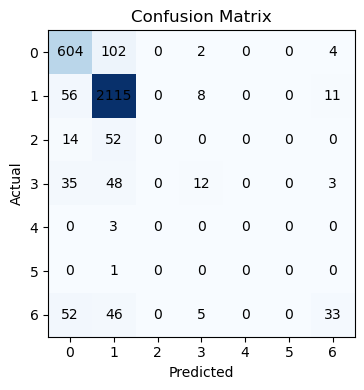

In [23]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# show numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [10]:
model.save("../models/landuse_cnn_model.keras")
print("Model saved")

Model saved
